## ProSafe Predictive Modeling Using KNN

The purpose of this working session was to explain the basics of the K-Nearest Neighbors regression algorithm and how it can be applied to create a machine learning model with the ProSafe dataset.

Our team decided not to leverage this technique in an official capacity in our project, as it is no longer widely used anymore out in the industry. However, by training such a model on our dataset, we were able to demonstrate how easy it is to train a simple dataset using KNN in Scikit-learn.

In [3]:
# Step 1: Library Imports

import pandas as pd
from pandasql import sqldf

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

In [4]:
# Step 2: Import CSV Files as Pandas Dataframes

base_dir = "./data_sources/prosafe_dataset"
policy_from_2011_to_2014 = pd.read_csv(f"{base_dir}/policy_from_2011_to_2014.csv")
policy_from_2014_to_2018 = pd.read_csv(f"{base_dir}/policy_from_2014_to_2018.csv")

In [5]:
# Step 3: Choose Input Feature(s) and Corresponding Predicted Output Feature

dataset = policy_from_2011_to_2014[['INSURED_VALUE', 'PREMIUM']].dropna()

X = dataset[['INSURED_VALUE']]
y = dataset[['PREMIUM']]

In [6]:
# Step 3a (Optional): Inspect and Filter Dataset if Applicable

print(f"Vehicle Value:\n\tMin: {X.min()}\n\tMax: {X.max()}")
print(f"Premium:\n\tMin: {y.min()}\n\tMax: {y.max()}")

greater_than_zero = sqldf("""
    SELECT * FROM policy_from_2011_to_2014
        WHERE INSURED_VALUE > 0;
""")
print("Greater Than Zero:", len(greater_than_zero))

zero = sqldf("""
    SELECT * FROM policy_from_2011_to_2014
        WHERE INSURED_VALUE = 0;
""")
print("Zero:", len(zero))

less_than_zero = sqldf("""
    SELECT * FROM policy_from_2011_to_2014
        WHERE INSURED_VALUE < 0;
""")
print("Less Than Zero:", len(less_than_zero))

Vehicle Value:
	Min: INSURED_VALUE    0.0
dtype: float64
	Max: INSURED_VALUE    250000000.0
dtype: float64
Premium:
	Min: PREMIUM    0.0
dtype: float64
	Max: PREMIUM    227278.88
dtype: float64
Greater Than Zero: 181429
Zero: 112108
Less Than Zero: 0


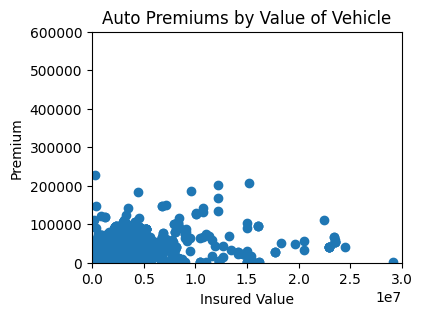

In [7]:
# Step 4 (Optional): Create a Graph Surrounding the Original Dataset

test_figure = plt.figure(figsize=(4, 3))

plt.scatter(X, y, color='#1f77b4')

plt.title("Auto Premiums by Value of Vehicle")
plt.xlabel('Insured Value')
plt.ylabel('Premium')

plt.ylim([0.00, 600_000.00])
plt.xlim([0.00, 30_000_000.00])

plt.show()

In [8]:
# Step 5: Create K-Nearest-Neighbors Regressor and Fit/Train Model

test_regressor = KNeighborsRegressor(n_neighbors=5)
test_model = test_regressor.fit(X, y)

In [9]:
# Step 6: Predict a New Output Given a New Input

# Suppose we bought a new vehicle and want to predict the insurance premium.
new_vehicle_value = [[20_000.00]]

# Predicted premium for the new vehicle.
predicted_premium = test_model.predict(new_vehicle_value)
predicted_premium

/opt/homebrew/anaconda3/envs/Anaconda/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


array([[1062.1442]])

In [13]:
# Step 7 (Optional): Inspect How Model Works with Nearest Values to Predicted Input

similar_policies = test_model.kneighbors(new_vehicle_value)
similar_policies

/opt/homebrew/anaconda3/envs/Anaconda/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


(array([[0., 0., 0., 0., 0.]]), array([[  942, 11362,   941,   265,  3832]]))